In [66]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from neo4j import GraphDatabase
import os
from dotenv import load_dotenv

In [2]:
df_med_sciences = pd.read_excel(r'data\studentcourses.xlsx', sheet_name="علوم طبية ")
df_med_sciences = pd.DataFrame(df_med_sciences)
df_med_sciences.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,NaN,1105312002,عبدالمجيد علي عبدالرحمن الشاوي,السجلات الطبية-2,110501,المهارات اللغوية,ARAB 101,211637
1,NaN,1105311013,سالم سليمان دهش الشمري,السجلات الطبية-2,110501,المهارات اللغوية,ARAB 101,211637
2,NaN,1105312004,احمد عبدالله صالح الحربي,السجلات الطبية-2,110511,التحرير العربي,ARAB 102,111647
3,NaN,1105321021,يوسف عبدالله سليمان المهوس,السجلات الطبية-2,110511,التحرير العربي,ARAB 102,211647
4,NaN,1105312011,سطام بندر جايز المطيري,السجلات الطبية-2,110511,التحرير العربي,ARAB 102,211647


In [3]:
df_med_sciences.info() #notice that the column names are unknown

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1262 entries, 0 to 1261
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  0 non-null      float64
 1   Unnamed: 1  1262 non-null   int64  
 2   Unnamed: 2  1262 non-null   object 
 3   Unnamed: 3  1262 non-null   object 
 4   Unnamed: 4  1262 non-null   int64  
 5   Unnamed: 5  1262 non-null   object 
 6   Unnamed: 6  1262 non-null   object 
 7   Unnamed: 7  1262 non-null   int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 79.0+ KB


In [4]:
df_MPD = pd.read_excel(r'data\studentcourses.xlsx', sheet_name="صيدلة وطب اسنان")
df_MPD = pd.DataFrame(df_MPD)
df_MPD.head()

,م,رقم الطالب,اسم الطالب,التخصص,رقم المقرر,اسم المقرر,رمز المقرر,رقم الشعبة
0,NaN,1.201321e+09,سعد عامر خضران الرشيدي,طب وجراحة الأسنان,120113.0,anatomy& histology,112 ana,212113.0
1,NaN,1.201321e+09,طارق حمود معجب الرشيدي,طب وجراحة الأسنان,120113.0,anatomy& histology,112 ana,212113.0
2,NaN,1.201321e+09,عبدالسلام فواز مقحم العقيلي المطيري,طب وجراحة الأسنان,120113.0,anatomy& histology,112 ana,212113.0
3,NaN,1.201321e+09,فهد سعود رباح الرشيدي,طب وجراحة الأسنان,120113.0,anatomy& histology,112 ana,212113.0
4,NaN,1.201321e+09,عبدالله دعيع عايض الرشيدي,طب وجراحة الأسنان,120113.0,anatomy& histology,112 ana,212113.0


In [5]:
df_MPD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3631 entries, 0 to 3630
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   م           140 non-null    object 
 1   رقم الطالب  2514 non-null   float64
 2   اسم الطالب  2514 non-null   object 
 3   التخصص      2514 non-null   object 
 4   رقم المقرر  2514 non-null   float64
 5   اسم المقرر  2514 non-null   object 
 6   رمز المقرر  2514 non-null   object 
 7   رقم الشعبة  2514 non-null   float64
dtypes: float64(3), object(5)
memory usage: 227.1+ KB


In [6]:
df_med_sciences.columns = df_MPD.columns #assign column names of MPD to med_sciences dataframe

In [7]:
df_med_sciences.head()

,م,رقم الطالب,اسم الطالب,التخصص,رقم المقرر,اسم المقرر,رمز المقرر,رقم الشعبة
0,NaN,1105312002,عبدالمجيد علي عبدالرحمن الشاوي,السجلات الطبية-2,110501,المهارات اللغوية,ARAB 101,211637
1,NaN,1105311013,سالم سليمان دهش الشمري,السجلات الطبية-2,110501,المهارات اللغوية,ARAB 101,211637
2,NaN,1105312004,احمد عبدالله صالح الحربي,السجلات الطبية-2,110511,التحرير العربي,ARAB 102,111647
3,NaN,1105321021,يوسف عبدالله سليمان المهوس,السجلات الطبية-2,110511,التحرير العربي,ARAB 102,211647
4,NaN,1105312011,سطام بندر جايز المطيري,السجلات الطبية-2,110511,التحرير العربي,ARAB 102,211647


In [8]:
df_med_sciences.drop(columns='م',inplace=True) #removes column م bec it is empty and unnecessary
df_med_sciences.head()

,رقم الطالب,اسم الطالب,التخصص,رقم المقرر,اسم المقرر,رمز المقرر,رقم الشعبة
0,1105312002,عبدالمجيد علي عبدالرحمن الشاوي,السجلات الطبية-2,110501,المهارات اللغوية,ARAB 101,211637
1,1105311013,سالم سليمان دهش الشمري,السجلات الطبية-2,110501,المهارات اللغوية,ARAB 101,211637
2,1105312004,احمد عبدالله صالح الحربي,السجلات الطبية-2,110511,التحرير العربي,ARAB 102,111647
3,1105321021,يوسف عبدالله سليمان المهوس,السجلات الطبية-2,110511,التحرير العربي,ARAB 102,211647
4,1105312011,سطام بندر جايز المطيري,السجلات الطبية-2,110511,التحرير العربي,ARAB 102,211647


In [9]:
df_med_sciences.isna().sum() #no null values

رقم الطالب    0
اسم الطالب    0
التخصص        0
رقم المقرر    0
اسم المقرر    0
رمز المقرر    0
رقم الشعبة    0
dtype: int64

In [10]:
df_med_sciences.duplicated().sum() #no duplicates

np.int64(0)

In [11]:
df_med_sciences.nunique()

رقم الطالب    244
اسم الطالب    244
التخصص          8
رقم المقرر    108
اسم المقرر    103
رمز المقرر    107
رقم الشعبة    137
dtype: int64

In [12]:
df_MPD.isna()

,م,رقم الطالب,اسم الطالب,التخصص,رقم المقرر,اسم المقرر,رمز المقرر,رقم الشعبة
0,True,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
3626,True,True,True,True,True,True,True,True
3627,True,True,True,True,True,True,True,True
3628,True,True,True,True,True,True,True,True
3629,True,True,True,True,True,True,True,True


In [13]:
df_MPD.drop(columns='م', inplace=True) #remove column full of null values first before removing rows with null values

In [14]:
df_MPD.dropna(inplace=True)
df_MPD.isna()

,رقم الطالب,اسم الطالب,التخصص,رقم المقرر,اسم المقرر,رمز المقرر,رقم الشعبة
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
2509,False,False,False,False,False,False,False
2510,False,False,False,False,False,False,False
2511,False,False,False,False,False,False,False
2512,False,False,False,False,False,False,False


In [15]:
df_MPD.drop_duplicates(inplace=True)
df_MPD.info() #notice floats, will convert them to integers to make values readable and consistent

<class 'pandas.core.frame.DataFrame'>
Index: 2514 entries, 0 to 2513
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   رقم الطالب  2514 non-null   float64
 1   اسم الطالب  2514 non-null   object 
 2   التخصص      2514 non-null   object 
 3   رقم المقرر  2514 non-null   float64
 4   اسم المقرر  2514 non-null   object 
 5   رمز المقرر  2514 non-null   object 
 6   رقم الشعبة  2514 non-null   float64
dtypes: float64(3), object(4)
memory usage: 157.1+ KB


In [16]:
df_MPD.nunique()

رقم الطالب    333
اسم الطالب    333
التخصص          3
رقم المقرر     99
اسم المقرر     96
رمز المقرر     99
رقم الشعبة    140
dtype: int64

In [17]:
df_MPD['رقم الطالب'] = df_MPD['رقم الطالب'].astype('int')
df_MPD['رقم المقرر'] = df_MPD['رقم المقرر'].astype('int')
df_MPD['رقم الشعبة'] = df_MPD['رقم الشعبة'].astype('int')
df_MPD.tail()

,رقم الطالب,اسم الطالب,التخصص,رقم المقرر,اسم المقرر,رمز المقرر,رقم الشعبة
2509,1202311090,سعود عبدالعزيز سعود العتيبي,الصيدلة الإكلينيكية,120227,ممارسة صيدلية,311 صكل,112201
2510,1202311008,عبدالكريم عبدالله خليف الخياري,العلوم الصيدلية,120227,ممارسة صيدلية,311 صكل,112201
2511,1202321053,رافت جمال خميس العلي,العلوم الصيدلية,120227,ممارسة صيدلية,311 صكل,112201
2512,1201302023,عادل ضافي عجب الحربي,طب وجراحة الأسنان,110155,مهارات الاتصال,140علم,211395
2513,1201311041,ريان فلاج فهد الفلاج,طب وجراحة الأسنان,110155,مهارات الاتصال,140علم,211395


In [18]:
df_business = pd.read_excel(r'data\studentcourses.xlsx', sheet_name="العلوم الادارية")
df_business = pd.DataFrame(df_business)
df_business.head()

,م,رقم الطالب,اسم الطالب,التخصص,رقم المقرر,اسم المقرر,رمز المقرر,رقم الشعبة
0,NaN,1302322004,عبدالعزيز صالح محمد الرميح,اللغات والترجمة,130218,المهارات اللغوية,ARAB 101,113197
1,NaN,1302322009,معاذ معتق صالح الشملاني العنزي,اللغات والترجمة,130218,المهارات اللغوية,ARAB 101,113197
2,NaN,1302321015,عبدالرحمن سليمان محمد الثنيان,اللغات والترجمة,130218,المهارات اللغوية,ARAB 101,113197
3,NaN,1302322007,محمد عبدالعزيز عبدالله الربيش,اللغات والترجمة,130218,المهارات اللغوية,ARAB 101,113197
4,NaN,1302322005,ابراهيم فهد ابراهيم الرباح,اللغات والترجمة,130225,APPLIED GRAMMAR2,ARAB102,113204


In [19]:
df_business.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7702 entries, 0 to 7701
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   م           571 non-null    object
 1   رقم الطالب  5417 non-null   object
 2   اسم الطالب  5417 non-null   object
 3   التخصص      5417 non-null   object
 4   رقم المقرر  5417 non-null   object
 5   اسم المقرر  5417 non-null   object
 6   رمز المقرر  5417 non-null   object
 7   رقم الشعبة  5417 non-null   object
dtypes: object(8)
memory usage: 481.5+ KB


In [20]:
df_business.drop_duplicates(inplace=True)
df_business.tail()

,م,رقم الطالب,اسم الطالب,التخصص,رقم المقرر,اسم المقرر,رمز المقرر,رقم الشعبة
7670,صفحة 282 / 286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7678,صفحة 283 / 286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7686,صفحة 284 / 286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7694,صفحة 285 / 286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7701,صفحة 286 / 286,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
df_business.isna()

,م,رقم الطالب,اسم الطالب,التخصص,رقم المقرر,اسم المقرر,رمز المقرر,رقم الشعبة
0,True,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
7670,False,True,True,True,True,True,True,True
7678,False,True,True,True,True,True,True,True
7686,False,True,True,True,True,True,True,True
7694,False,True,True,True,True,True,True,True


In [22]:
df_business = df_business.drop(df_business[df_business['م'] == 'م'].index) #rows with value م in column م were irrelevant 
df_business.tail()

,م,رقم الطالب,اسم الطالب,التخصص,رقم المقرر,اسم المقرر,رمز المقرر,رقم الشعبة
7670,صفحة 282 / 286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7678,صفحة 283 / 286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7686,صفحة 284 / 286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7694,صفحة 285 / 286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7701,صفحة 286 / 286,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df_business.drop(columns='م',inplace=True)

In [24]:
df_business.dropna(inplace=True)
df_business.tail()

,رقم الطالب,اسم الطالب,التخصص,رقم المقرر,اسم المقرر,رمز المقرر,رقم الشعبة
5412,1305321034,محسن سعيد محسن العساف,المحاسبة,130536,نظم المعلومات المحاسبية,حسب461,213325
5413,1305312007,فهد عبدالعزيز عبدالله المحسن,المحاسبة,130536,نظم المعلومات المحاسبية,حسب461,113325
5414,1305311003,علي صالح علي العباد,المحاسبة,130536,نظم المعلومات المحاسبية,حسب461,213325
5415,1305312018,حسين محمد عبدالرحمن الهذلول,المحاسبة,130536,نظم المعلومات المحاسبية,حسب461,213325
5416,1305312011,مهران علي سليمان الحجي,المحاسبة,130536,نظم المعلومات المحاسبية,حسب461,113325


In [25]:
df_business.isna().sum()

رقم الطالب    0
اسم الطالب    0
التخصص        0
رقم المقرر    0
اسم المقرر    0
رمز المقرر    0
رقم الشعبة    0
dtype: int64

In [26]:
df_business['رقم الطالب'] = df_business['رقم الطالب'].astype('int')
df_business['رقم الشعبة'] = df_business['رقم الشعبة'].astype('int')
df_business.tail()

,رقم الطالب,اسم الطالب,التخصص,رقم المقرر,اسم المقرر,رمز المقرر,رقم الشعبة
5412,1305321034,محسن سعيد محسن العساف,المحاسبة,130536,نظم المعلومات المحاسبية,حسب461,213325
5413,1305312007,فهد عبدالعزيز عبدالله المحسن,المحاسبة,130536,نظم المعلومات المحاسبية,حسب461,113325
5414,1305311003,علي صالح علي العباد,المحاسبة,130536,نظم المعلومات المحاسبية,حسب461,213325
5415,1305312018,حسين محمد عبدالرحمن الهذلول,المحاسبة,130536,نظم المعلومات المحاسبية,حسب461,213325
5416,1305312011,مهران علي سليمان الحجي,المحاسبة,130536,نظم المعلومات المحاسبية,حسب461,113325


In [27]:
df_engineering = pd.read_excel(r'data\studentcourses.xlsx', sheet_name="الهندسة")
df_engineering = pd.DataFrame(df_engineering)
df_engineering.head()

,م,رقم الطالب,اسم الطالب,التخصص,رقم المقرر,اسم المقرر,رمز المقرر,رقم الشعبة
0,NaN,1402311001,متعب عواد خضير الحربي,اتصالات و إلكترونيات,240610,اتصالات الاقمار الصناعية,425 كهر,240610
1,NaN,1402311010,ريان ناصر عبدالله العسيمي,اتصالات و إلكترونيات,240610,اتصالات الاقمار الصناعية,425 كهر,240610
2,NaN,1402311006,فيصل عبدالله سليمان الدرع,اتصالات و إلكترونيات,240610,اتصالات الاقمار الصناعية,425 كهر,240610
3,NaN,1402311007,سحمي سند سحمي السبيعي,اتصالات و إلكترونيات,240610,اتصالات الاقمار الصناعية,425 كهر,240610
4,NaN,1402311002,أحمد عبدالرحمن عبدالله اليوسف,اتصالات و إلكترونيات,240610,اتصالات الاقمار الصناعية,425 كهر,240610


In [28]:
df_engineering.isna().sum()

م             1374
رقم الطالب       0
اسم الطالب       0
التخصص           0
رقم المقرر       0
اسم المقرر       0
رمز المقرر       0
رقم الشعبة       0
dtype: int64

In [29]:
df_engineering.duplicated().sum()

np.int64(0)

In [30]:
df_engineering.drop(columns='م', inplace=True)
df_engineering.tail()

,رقم الطالب,اسم الطالب,التخصص,رقم المقرر,اسم المقرر,رمز المقرر,رقم الشعبة
1369,1401311006,عبدالله صالح سليمان الحسون,قوي كهربائية,140400,هندسة الجهد العالي,446 كهر,240400
1370,1401312031,عبدالله سليم محمود البلعاوي,قوي كهربائية,140400,هندسة الجهد العالي,446 كهر,240400
1371,1401311011,مؤيد فهد سليمان الحصان,قوي كهربائية,140400,هندسة الجهد العالي,446 كهر,240400
1372,1401311010,فهد علي محمد المعارك,قوي كهربائية,140400,هندسة الجهد العالي,446 كهر,240400
1373,1401312022,احمد راضي صالح الشمري,قوي كهربائية,140400,هندسة الجهد العالي,446 كهر,240400


In [31]:
df_engineering.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1374 entries, 0 to 1373
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   رقم الطالب  1374 non-null   int64 
 1   اسم الطالب  1374 non-null   object
 2   التخصص      1374 non-null   object
 3   رقم المقرر  1374 non-null   int64 
 4   اسم المقرر  1374 non-null   object
 5   رمز المقرر  1374 non-null   object
 6   رقم الشعبة  1374 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 75.3+ KB


In [32]:
df_cs = pd.read_excel(r'data\studentcourses.xlsx', sheet_name="حاسب الي")
df_cs = pd.DataFrame(df_cs)
df_cs.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,م,رقم الطالب,اسم الطالب,التخصص,رقم المقرر,اسم المقرر,رمز المقرر,رقم الشعبة
1,1,1502302012,محمد سليمان محمد الخضيري,علوم الحاسب,150290,اختياري قسم,عال,215245
2,2,1502321001,عبدالله حمد ابراهيم الصائغ,علوم الحاسب,150286,اختياري قسم,عال,115242
3,3,1501321027,عبدالرحمن محمد ابراهيم العيسوي,هندسة الحاسب,150315,اختياري قسم,عال,115252
4,4,1501321027,عبدالرحمن محمد ابراهيم العيسوي,هندسة الحاسب,150316,اختياري قسم,عال,115253


In [33]:
df_cs.duplicated().sum()

np.int64(0)

In [34]:
df_cs.isna().sum()

Unnamed: 0    0
Unnamed: 1    0
Unnamed: 2    0
Unnamed: 3    0
Unnamed: 4    0
Unnamed: 5    0
Unnamed: 6    0
Unnamed: 7    0
dtype: int64

In [35]:
df_cs.drop(columns='Unnamed: 0', inplace=True)
df_cs.columns = df_business.columns
df_cs.head()

,رقم الطالب,اسم الطالب,التخصص,رقم المقرر,اسم المقرر,رمز المقرر,رقم الشعبة
0,رقم الطالب,اسم الطالب,التخصص,رقم المقرر,اسم المقرر,رمز المقرر,رقم الشعبة
1,1502302012,محمد سليمان محمد الخضيري,علوم الحاسب,150290,اختياري قسم,عال,215245
2,1502321001,عبدالله حمد ابراهيم الصائغ,علوم الحاسب,150286,اختياري قسم,عال,115242
3,1501321027,عبدالرحمن محمد ابراهيم العيسوي,هندسة الحاسب,150315,اختياري قسم,عال,115252
4,1501321027,عبدالرحمن محمد ابراهيم العيسوي,هندسة الحاسب,150316,اختياري قسم,عال,115253


In [36]:
df_cs.drop(index=0, inplace=True) #drop first row

In [37]:
df_cs.iloc[:,4].nunique()

87

In [38]:
all_dfs = pd.concat([df_med_sciences, df_MPD, df_business, df_engineering, df_cs]) #merge all dataframes vertically
all_dfs

,رقم الطالب,اسم الطالب,التخصص,رقم المقرر,اسم المقرر,رمز المقرر,رقم الشعبة
0,1105312002,عبدالمجيد علي عبدالرحمن الشاوي,السجلات الطبية-2,110501,المهارات اللغوية,ARAB 101,211637
1,1105311013,سالم سليمان دهش الشمري,السجلات الطبية-2,110501,المهارات اللغوية,ARAB 101,211637
2,1105312004,احمد عبدالله صالح الحربي,السجلات الطبية-2,110511,التحرير العربي,ARAB 102,111647
3,1105321021,يوسف عبدالله سليمان المهوس,السجلات الطبية-2,110511,التحرير العربي,ARAB 102,211647
4,1105312011,سطام بندر جايز المطيري,السجلات الطبية-2,110511,التحرير العربي,ARAB 102,211647
...,...,...,...,...,...,...,...
817,1501311010,أحمد عبدالعزيز محمد العبيدان,هندسة الحاسب,150147,هندسة البرمجيات,342عال,215153
818,1401321075,صالح محمد صالح الرميح,علوم الحاسب,150147,هندسة البرمجيات,342عال,115152
819,1502301005,يزيد محمد صالح الهجرس,علوم حاسب-1,150147,هندسة البرمجيات,342عال,115155
820,1502312010,محمد عبدالله محيميد العريني,علوم الحاسب,150147,هندسة البرمجيات,342عال,115152


In [39]:
courses = all_dfs.groupby(['رقم المقرر', 'اسم المقرر']).size().reset_index(name='عدد المسجلين') #counts number of occurence of course in the dataframe
courses

,رقم المقرر,اسم المقرر,عدد المسجلين
0,110101,المهارات اللغوية,159
1,110102,المدخل إلي الثقافة الاسلامية,114
2,110111,التحرير العربي,150
3,110112,علم الإحصاء الحيوي المتقدم,53
4,110113,مهن ونظم الرعاية الصحية,5
...,...,...,...
491,150315,اختياري قسم,16
492,150316,اختياري قسم,13
493,240608,الاتصالات الرقمية,8
494,240609,انتشار الموجات والهوئيات,8


In [40]:
students = all_dfs.groupby(['رقم الطالب', 'اسم الطالب'])[['رقم المقرر']].count().reset_index().rename(columns={'رقم المقرر': 'عدد المقررات المسجلة'})
students

,رقم الطالب,اسم الطالب,عدد المقررات المسجلة
0,1101301001,تركي فهد سليمان الحجيلي,7
1,1101302002,متعب علي صالح العقلاء,6
2,1101302003,عبدالعزيز أحمد صالح الخريصي,7
3,1101302004,راضي عبدالله سليمان الراضي,7
4,1101302005,عبدالرحمن ابراهيم عبدالرحمن الرشودي,7
...,...,...,...
1815,1502331010,عبدالله صالح سليمان الخريف,7
1816,1502331012,محمد عبدالرحمن خضير الفريدي الحربي,7
1817,1502331013,صالح معلاء صياح الحربي,7
1818,1502331015,علي حمد عبدالله الخلف,5


In [41]:
students_courses = all_dfs.groupby('رقم الطالب')['رقم المقرر'].apply(list) #creates a series, index is student id and values are the courses they enrolled in
students_courses[1101301001]

[110164, 110163, 110139, 110140, 110138, 110137, 110134]

In [42]:
g = nx.Graph() #create graph
for index, row in courses.iterrows():
    g.add_node(row['رقم المقرر'] ,attr={'اسم المقرر':row['اسم المقرر'], 'عدد المسجلين':row['عدد المسجلين']}) #add courses as nodes in the graph and give them attributes
g.number_of_nodes()

496

In [43]:
for course_list in students_courses: #for adding edges between nodes, concept : if a student is enrolled in course A and course B add an edge between their nodes
    for i in range(len(course_list)): #so as to create an exam schedule without conflicts
        for j in range(i+1, len(course_list)):
            course1 = course_list[i]
            course2 = course_list[j]
            if g.has_edge(course1, course2):
                g[course1][course2]['weight'] += 1
            else:
                g.add_edge(course1, course2, weight=1) #weight of an edge will be the number of students enrolled in both of course1 and course2

In [44]:
g.nodes[110102]['attr']['عدد المسجلين']

114

In [45]:
g[110102][110115]['weight'] #edges connected to node 110102

15

In [46]:
g.number_of_edges()

5414

In [47]:
g.degree(110102)

87

In [48]:
g.edges()

EdgeView([(110101, 110315), (110101, 110316), (110101, 110343), (110101, 110123), (110101, 110330), (110101, 110333), (110101, 110327), (110101, 110130), (110101, 110129), (110101, 130608), (110101, 130605), (110101, 130606), (110101, 130607), (110101, 130609), (110101, 110156), (110101, 110102), (110101, 140117), (110101, 140191), (110101, 110117), (110101, 140178), (110101, 140181), (110101, 120221), (110101, 120233), (110101, 120220), (110101, 140179), (110101, 140177), (110101, 140175), (110101, 130614), (110101, 110115), (110101, 120222), (110101, 120223), (110101, 120217), (110101, 120218), (110101, 120287), (110101, 120241), (110101, 120225), (110101, 120290), (110101, 120292), (110101, 120243), (110101, 120242), (110101, 120236), (110101, 120235), (110101, 120215), (110101, 120213), (110101, 120227), (110101, 120291), (110101, 120283), (110101, 120232), (110101, 120234), (110101, 120254), (110101, 120237), (110101, 120238), (110101, 120228), (110101, 120240), (110101, 120250), 

<Figure size 1200x1000 with 0 Axes>

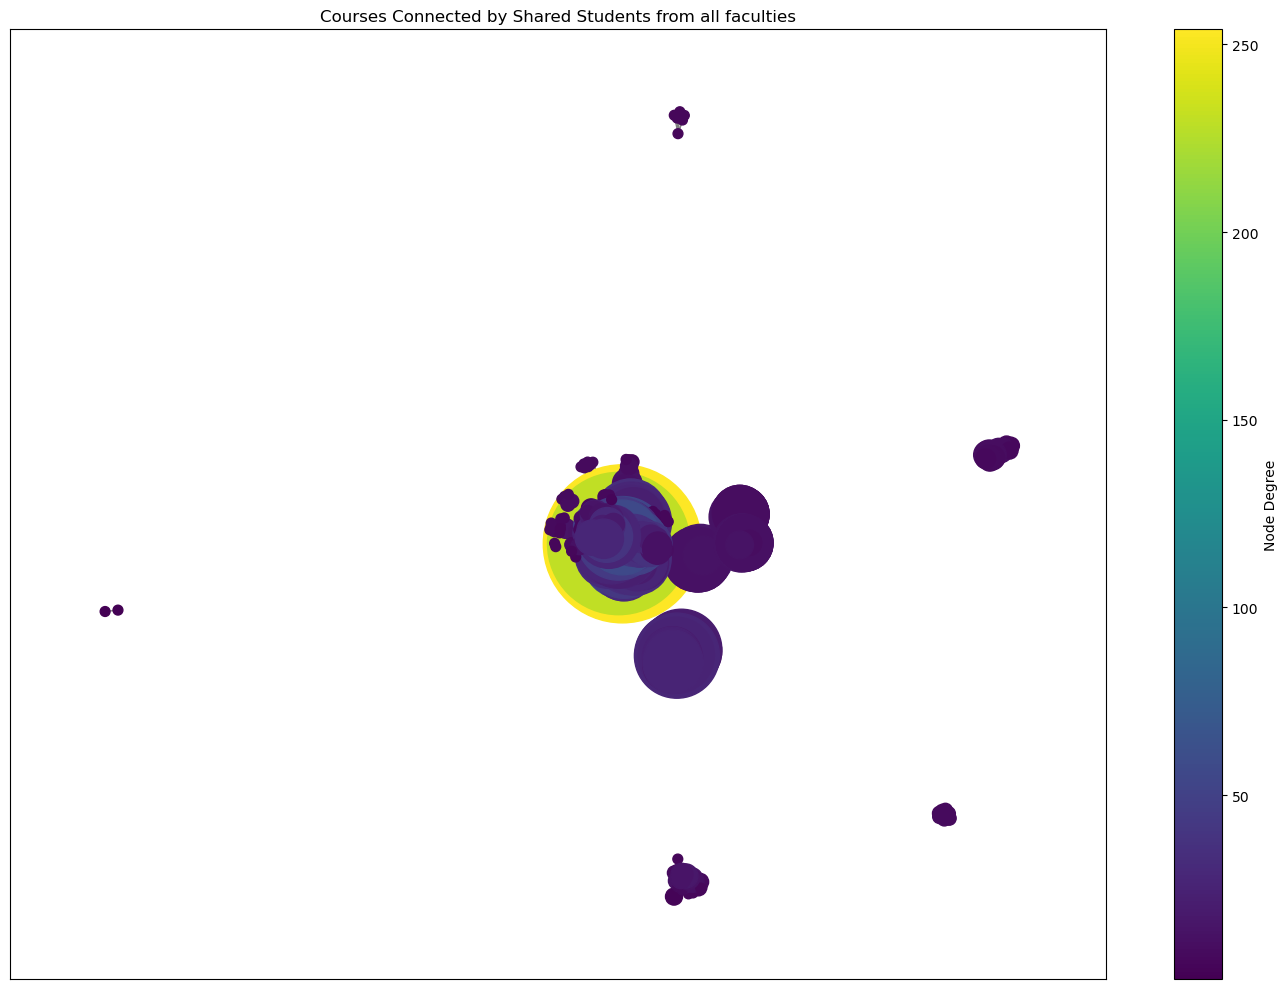

In [56]:
plt.figure(figsize=(12,10))
pos = nx.spring_layout(g, seed=42)

node_sizes = [g.nodes[node]['attr']['عدد المسجلين'] * 50 for node in g.nodes()] #node size represents no. of students enrolled in course

node_colors = [g.degree(node) for node in g.nodes()] #node color represents degree of each node

# labels = {node: g.nodes[node]['attr']['اسم المقرر'] for node in g.nodes()}
labels = {node: node for node in g.nodes()}

fig, ax = plt.subplots(figsize=(14, 10))

nodes = nx.draw_networkx_nodes(
    g, pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.viridis,
    ax=ax
)

nx.draw_networkx_edges(
    g, pos,
    edge_color='gray',
    ax=ax
)


sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, 
                          norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array(node_colors)
plt.colorbar(sm, ax=ax, label="Node Degree")

plt.title("Courses Connected by Shared Students from all faculties")
plt.tight_layout()
plt.show()

In [ ]:

# AUTH = 

with GraphDatabase.driver(uri, auth=(username, password) ) as driver:
    driver.verify_connectivity()
    print("Connection established.")

Connection established.


In [77]:
driver.close()

In [63]:
g[110101]

AtlasView({110315: {'weight': 1}, 110316: {'weight': 1}, 110343: {'weight': 1}, 110123: {'weight': 17}, 110330: {'weight': 1}, 110333: {'weight': 1}, 110327: {'weight': 1}, 110130: {'weight': 1}, 110129: {'weight': 1}, 130608: {'weight': 47}, 130605: {'weight': 47}, 130606: {'weight': 49}, 130607: {'weight': 51}, 130609: {'weight': 50}, 110156: {'weight': 16}, 110102: {'weight': 75}, 140117: {'weight': 5}, 140191: {'weight': 1}, 110117: {'weight': 14}, 140178: {'weight': 16}, 140181: {'weight': 21}, 120221: {'weight': 11}, 120233: {'weight': 3}, 120220: {'weight': 3}, 140179: {'weight': 18}, 140177: {'weight': 19}, 140175: {'weight': 2}, 130614: {'weight': 8}, 110115: {'weight': 24}, 120222: {'weight': 10}, 120223: {'weight': 12}, 120217: {'weight': 8}, 120218: {'weight': 10}, 120287: {'weight': 1}, 120241: {'weight': 4}, 120225: {'weight': 5}, 120290: {'weight': 2}, 120292: {'weight': 2}, 120243: {'weight': 7}, 120242: {'weight': 3}, 120236: {'weight': 6}, 120235: {'weight': 4}, 12021

In [78]:
load_dotenv()
uri = str(os.getenv('URI'))
username = str(os.getenv('NEO4J_USERNAME'))
password = str(os.getenv('NEO4J_PASSWORD'))

with GraphDatabase.driver(uri, auth=(username, password)) as driver:
    try:

        # First delete all existing data
        driver.execute_query("MATCH (n) DETACH DELETE n", database_="neo4j")
        # Create some nodes
        for node in g.nodes():
            attr = g.nodes[node].get('attr', {})
            records, summary, keys = driver.execute_query(
                "MERGE (c:course {id: $id, name: $name, noStudents: $noStudents})",
                id=node,
                name=attr.get("اسم المقرر", ""),
                noStudents=attr.get("عدد المسجلين", 0),
                database_="neo4j",
            )

        # Create relationships with weight property
        for source, target in g.edges():
            weight = g[source][target].get('weight', 0)  # Default to 0 if weight doesn't exist
            records, summary, keys = driver.execute_query("""
                MATCH (a:course {id: $source})
                MATCH (b:course {id: $target})
                MERGE (a)-[r:RELATED_TO {weight: $weight}]-(b)
                """,
                source=source, 
                target=target,
                weight=weight,
                database_="neo4j",
            )
                
        # Retrieve courses with relationships and weight > 0
        records, summary, keys = driver.execute_query("""
            MATCH (c:course)-[r:RELATED_TO]-(other:course)
            WHERE c.noStudents > $num AND r.weight > 0
            RETURN c, r.weight as relationship_weight
            """, 
            num=50,
            database_="neo4j",
        )
        
        # Loop through results and do something with them
        for record in records:
            print(f"Course: {record['c']}, Relationship Weight: {record['relationship_weight']}")
        
        # Summary information
        print("The query `{query}` returned {records_count} records in {time} ms.".format(
            query=summary.query, 
            records_count=len(records),
            time=summary.result_available_after
        ))

    except Exception as e:
        print(e)
        # further logging/processing

Course: <Node element_id='4:c51de3c5-924e-480e-a126-2da675b40b84:24' labels=frozenset({'course'}) properties={'name': 'علم الوبائيات 1', 'id': 110228, 'noStudents': 55}>, Relationship Weight: 13
Course: <Node element_id='4:c51de3c5-924e-480e-a126-2da675b40b84:24' labels=frozenset({'course'}) properties={'name': 'علم الوبائيات 1', 'id': 110228, 'noStudents': 55}>, Relationship Weight: 10
Course: <Node element_id='4:c51de3c5-924e-480e-a126-2da675b40b84:24' labels=frozenset({'course'}) properties={'name': 'علم الوبائيات 1', 'id': 110228, 'noStudents': 55}>, Relationship Weight: 8
Course: <Node element_id='4:c51de3c5-924e-480e-a126-2da675b40b84:24' labels=frozenset({'course'}) properties={'name': 'علم الوبائيات 1', 'id': 110228, 'noStudents': 55}>, Relationship Weight: 13
Course: <Node element_id='4:c51de3c5-924e-480e-a126-2da675b40b84:24' labels=frozenset({'course'}) properties={'name': 'علم الوبائيات 1', 'id': 110228, 'noStudents': 55}>, Relationship Weight: 3
Course: <Node element_id='4

In [79]:
med_sci_courses = df_med_sciences.groupby(['رقم المقرر', 'اسم المقرر']).size().reset_index(name='عدد المسجلين') #just wanted to visualize a graph with fewer nodes
med_sci_courses

,رقم المقرر,اسم المقرر,عدد المسجلين
0,110101,المهارات اللغوية,2
1,110102,المدخل إلي الثقافة الاسلامية,3
2,110111,التحرير العربي,23
3,110112,علم الإحصاء الحيوي المتقدم,53
4,110113,مهن ونظم الرعاية الصحية,5
...,...,...,...
103,110644,السلوك الانساني,1
104,110646,مكونات الأطعمة ذات التأثير العلاجي,1
105,110649,التثقيف الغذائي وارشاد الرضى,1
106,110650,ممارسه اكلينيكيه في التغذية2,1


In [80]:
med_sci_students_courses = df_med_sciences.groupby('رقم الطالب')['رقم المقرر'].apply(list)
med_sci_students_courses

رقم الطالب
1101301001    [110164, 110163, 110139, 110140, 110138, 11013...
1101302002     [110141, 110139, 110138, 110137, 110136, 110135]
1101302003    [110164, 110163, 110143, 110139, 110140, 11014...
1101302004    [110164, 110163, 110143, 110139, 110140, 11014...
1101302005    [110164, 110163, 110143, 110139, 110140, 11014...
                                    ...                        
1105321027    [110539, 110527, 110537, 110536, 110522, 11052...
1105321035             [110534, 110537, 110536, 110545, 110544]
1106311001    [110649, 110644, 110651, 110114, 110641, 11064...
1202322002     [110324, 110111, 110317, 110315, 110117, 110312]
1501321005     [110122, 110163, 110114, 110130, 110119, 110118]
Name: رقم المقرر, Length: 244, dtype: object

In [81]:
g_med_sci = nx.Graph()
for index, row in med_sci_courses.iterrows():
    g_med_sci.add_node(row['رقم المقرر'] ,attr={'اسم المقرر':row['اسم المقرر'], 'عدد المسجلين':row['عدد المسجلين']})
g_med_sci.number_of_nodes()

108

In [82]:
for course_list in med_sci_students_courses:
    for i in range(len(course_list)):
        for j in range(i+1, len(course_list)):
            course1 = course_list[i]
            course2 = course_list[j]
            if g_med_sci.has_edge(course1, course2):
                g_med_sci[course1][course2]['weight'] += 1
            else:
                g_med_sci.add_edge(course1, course2, weight=1)

In [83]:
g_med_sci[110112]

AtlasView({110115: {'weight': 3}, 110111: {'weight': 5}, 110119: {'weight': 3}, 110118: {'weight': 3}, 110113: {'weight': 1}, 110122: {'weight': 2}, 110114: {'weight': 2}, 110337: {'weight': 11}, 110336: {'weight': 8}, 110228: {'weight': 13}, 110338: {'weight': 6}, 110342: {'weight': 4}, 110341: {'weight': 2}, 110332: {'weight': 25}, 110335: {'weight': 17}, 110325: {'weight': 2}, 110326: {'weight': 6}, 110343: {'weight': 3}, 110128: {'weight': 7}, 110327: {'weight': 10}, 110331: {'weight': 14}, 110333: {'weight': 7}, 110315: {'weight': 5}, 110330: {'weight': 10}, 110129: {'weight': 9}, 110117: {'weight': 9}, 110310: {'weight': 2}, 110123: {'weight': 5}, 110130: {'weight': 6}, 110304: {'weight': 1}, 110340: {'weight': 3}, 110311: {'weight': 3}, 110303: {'weight': 4}, 110317: {'weight': 1}, 110316: {'weight': 3}, 110302: {'weight': 1}, 110309: {'weight': 3}})

In [84]:
g.nodes()
g.number_of_nodes()

496

In [85]:
g_med_sci.nodes[110164]

{'attr': {'اسم المقرر': 'المدخل إلى الثقافة الإسلامية', 'عدد المسجلين': 16}}

<Figure size 1200x800 with 0 Axes>

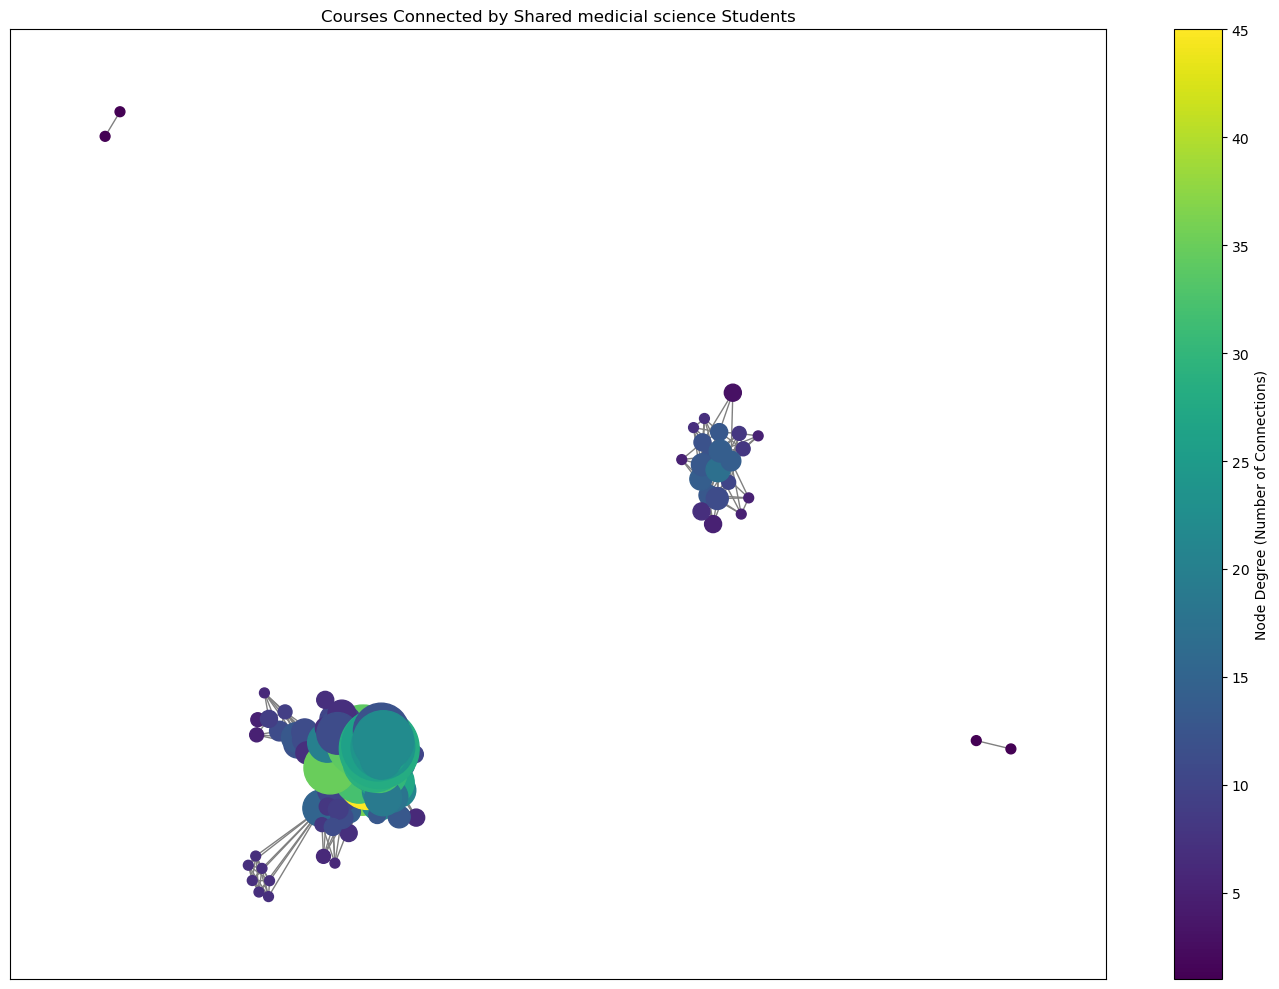

In [ ]:
plt.figure(figsize=(12,8))
pos = nx.spring_layout(g_med_sci, seed=42)

node_sizes = [g_med_sci.nodes[node]['attr']['عدد المسجلين'] * 50 for node in g_med_sci.nodes()]

node_colors = [g_med_sci.degree(node) for node in g_med_sci.nodes()]

# labels = {node: g_med_sci.nodes[node]['attr']['اسم المقرر'] for node in g_med_sci.nodes()}
labels = {node: node for node in g_med_sci.nodes()}

fig, ax = plt.subplots(figsize=(14, 10))

nodes = nx.draw_networkx_nodes(
    g_med_sci, pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.viridis,
    ax=ax
)

nx.draw_networkx_edges(
    g_med_sci, pos,
    edge_color='gray',
    ax=ax
)


sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, 
                          norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array(node_colors)
plt.colorbar(sm, ax=ax, label="Node Degree (Number of Connections)")

plt.title("Courses Connected by Shared medicial science Students")
plt.tight_layout()
plt.show()

In [87]:
coloring = nx.coloring.greedy_color(g, strategy='largest_first') #coloring algorithm is a greedy algorithm that prioritizes nodes with higher degrees
# nx.set_node_attributes(g, coloring, "color")

In [88]:
g.nodes()[110164]

{'attr': {'اسم المقرر': 'المدخل إلى الثقافة الإسلامية', 'عدد المسجلين': 16}}

In [89]:
coloring #a dict where each node is a key and its value is the color assigned by the algorithm

{110117: 0,
 110123: 1,
 110115: 2,
 110111: 3,
 110101: 4,
 110102: 5,
 140189: 6,
 120243: 5,
 120250: 6,
 110155: 3,
 130106: 6,
 140132: 3,
 120244: 7,
 140185: 7,
 120236: 8,
 120241: 9,
 120256: 10,
 120225: 11,
 120242: 12,
 140117: 8,
 140190: 9,
 120217: 13,
 120240: 14,
 130109: 7,
 120287: 2,
 120291: 11,
 130121: 5,
 140178: 10,
 150147: 2,
 120228: 15,
 110158: 9,
 120218: 8,
 120238: 16,
 120292: 17,
 130120: 8,
 140186: 11,
 120222: 15,
 120223: 0,
 120254: 13,
 110156: 0,
 120252: 1,
 120290: 3,
 120295: 4,
 130108: 12,
 140183: 4,
 120251: 15,
 120288: 14,
 140199: 5,
 150271: 7,
 120234: 10,
 120253: 18,
 140150: 2,
 140194: 1,
 110112: 4,
 120233: 9,
 120245: 8,
 130107: 2,
 140266: 6,
 140267: 9,
 120211: 12,
 120255: 19,
 120283: 17,
 130113: 9,
 130115: 6,
 130119: 9,
 140196: 0,
 140198: 10,
 110163: 2,
 120215: 6,
 120229: 20,
 120246: 0,
 140200: 13,
 110228: 0,
 120249: 16,
 130127: 4,
 110128: 5,
 120284: 20,
 140184: 5,
 110129: 2,
 110130: 6,
 110326: 7,
 1

In [90]:
color_courses = {}
for course, color in coloring.items():
    if color not in color_courses:
        color_courses[color] = []
    color_courses[color].append(course) #group courses by their color
color_courses[5] #courses that have the color 5

[110102,
 120243,
 130121,
 140199,
 110128,
 140184,
 110316,
 120294,
 130126,
 140152,
 150316,
 130619,
 110338,
 130525,
 130428,
 150270,
 130130,
 130626,
 130641,
 130613,
 110309,
 130412,
 130414,
 130105,
 110327,
 110113,
 120143,
 130440,
 150192,
 110521,
 120112,
 140601,
 110219,
 110134,
 120125,
 130222,
 150238,
 110434,
 110543,
 120133,
 110231,
 110525,
 110649,
 130261,
 150145,
 130215,
 150132,
 150246,
 150247,
 110136,
 110512,
 130211]

In [91]:
color_stats = []

for color, courses in color_courses.items():
    total_students = sum(g.nodes[c]['attr']['عدد المسجلين'] for c in courses)
    color_stats.append((color, total_students, courses))


color_stats.sort(key=lambda x: -x[1])
color_stats # a list that contains tuples of color, total num of students enrolled in the courses with this color, list of these courses ordered from highest to lowest degrees

[(5,
  1050,
  [110102,
   120243,
   130121,
   140199,
   110128,
   140184,
   110316,
   120294,
   130126,
   140152,
   150316,
   130619,
   110338,
   130525,
   130428,
   150270,
   130130,
   130626,
   130641,
   130613,
   110309,
   130412,
   130414,
   130105,
   110327,
   110113,
   120143,
   130440,
   150192,
   110521,
   120112,
   140601,
   110219,
   110134,
   120125,
   130222,
   150238,
   110434,
   110543,
   120133,
   110231,
   110525,
   110649,
   130261,
   150145,
   130215,
   150132,
   150246,
   150247,
   110136,
   110512,
   130211]),
 (3,
  974,
  [110111,
   110155,
   140132,
   120290,
   140172,
   110332,
   130125,
   150191,
   130143,
   130522,
   130442,
   110340,
   130609,
   130634,
   110164,
   120219,
   130104,
   130638,
   140192,
   130413,
   130421,
   130645,
   130410,
   150276,
   110522,
   120136,
   120262,
   130533,
   150144,
   110529,
   150274,
   120101,
   140276,
   150283,
   120122,
   130220,
   13

In [92]:
#constraints
STUDENT_LIMIT_PER_DAY = 2000
PERIODS_PER_DAY = 5


schedule = {}
day = 1
current_day_students = 0
current_period = 1

for color, total_students, course_list in color_stats:
    if current_period > PERIODS_PER_DAY or current_day_students + total_students > STUDENT_LIMIT_PER_DAY:
        day += 1
        current_period = 1
        current_day_students = 0
    
    if day not in schedule:
        schedule[day] = []
    
    schedule[day].append({
        "period": current_period,
        "courses": course_list,
        "students": total_students
    }) #this will create a dict where the day is they key and its values are the periods in that day
    
    current_day_students += total_students
    current_period += 1

In [93]:
for d, periods in schedule.items():
    print(f"Day {d}:")
    for p in periods:
        print(f"  Period {p['period']} -> {len(p['courses'])} courses, {p['students']} students")


Day 1:
  Period 1 -> 52 courses, 1050 students
Day 2:
  Period 1 -> 49 courses, 974 students
  Period 2 -> 45 courses, 972 students
Day 3:
  Period 1 -> 44 courses, 929 students
  Period 2 -> 47 courses, 895 students
Day 4:
  Period 1 -> 27 courses, 881 students
  Period 2 -> 36 courses, 847 students
Day 5:
  Period 1 -> 43 courses, 842 students
  Period 2 -> 40 courses, 821 students
Day 6:
  Period 1 -> 31 courses, 796 students
  Period 2 -> 21 courses, 615 students
  Period 3 -> 17 courses, 405 students
Day 7:
  Period 1 -> 11 courses, 376 students
  Period 2 -> 9 courses, 174 students
  Period 3 -> 8 courses, 142 students
  Period 4 -> 7 courses, 132 students
  Period 5 -> 3 courses, 84 students
Day 8:
  Period 1 -> 2 courses, 68 students
  Period 2 -> 2 courses, 47 students
  Period 3 -> 1 courses, 34 students
  Period 4 -> 1 courses, 19 students


In [94]:
rows = []

for day, periods in schedule.items():
    for p in periods:
        period = p['period']
        for course in p['courses']:
            course_name = g.nodes[course]['attr']['اسم المقرر']
            rows.append({
                'Day': day,
                'Period': period,
                'Course ID': course,
                'Course Name': course_name,
            })

df_schedule = pd.DataFrame(rows)

df_schedule.to_excel("Exam_Schedule.xlsx", index=False, engine='openpyxl')


In [95]:
g2 = g.copy()

In [96]:
coloring_dsat = nx.coloring.greedy_color(g2, strategy='DSATUR') #dsaturation strategy, which is also a greedy algorithm, but this one is slower and more efficient(number of colors will be less)

In [97]:
color_courses2= {}
for course, color in coloring_dsat.items():
    if color not in color_courses2:
        color_courses2[color] = []
    color_courses2[color].append(course)

color_stats2= []

for color, courses in color_courses2.items():
    total_students2 = sum(g2.nodes[c]['attr']['عدد المسجلين'] for c in courses)
    color_stats2.append((color, total_students2, courses))


# color_stats2.sort(key=lambda x: -x[1])

#constraints
STUDENT_LIMIT_PER_DAY = 2000
PERIODS_PER_DAY = 5


schedule2 = {}
day = 1
current_day_students = 0
current_period = 1

for color, total_students, course_list in color_stats2:
    if current_period > PERIODS_PER_DAY or current_day_students + total_students > STUDENT_LIMIT_PER_DAY:
        day += 1
        current_period = 1
        current_day_students = 0
    
    if day not in schedule2:
        schedule2[day] = []
    
    schedule2[day].append({
        "period": current_period,
        "courses": course_list,
        "students": total_students
    })
    
    current_day_students += total_students
    current_period += 1

for d, periods in schedule2.items():
    print(f"Day {d}:")
    for p in periods:
        print(f"  Period {p['period']} -> {len(p['courses'])} courses, {p['students']} students") #notice less days (periods))-> less colors
        #dsaturation algorithm is not deterministic, might get a different answer with each run
        #because it checks for the saturation of the neighbors of the node at each step thats why the largest first strategy is faster (it assigns the colors in one pass)

Day 1:
  Period 1 -> 51 courses, 952 students
  Period 2 -> 49 courses, 910 students
Day 2:
  Period 1 -> 50 courses, 1060 students
  Period 2 -> 50 courses, 889 students
Day 3:
  Period 1 -> 45 courses, 978 students
  Period 2 -> 46 courses, 932 students
Day 4:
  Period 1 -> 41 courses, 837 students
  Period 2 -> 35 courses, 912 students
Day 5:
  Period 1 -> 29 courses, 779 students
  Period 2 -> 26 courses, 777 students
Day 6:
  Period 1 -> 23 courses, 685 students
  Period 2 -> 18 courses, 576 students
  Period 3 -> 12 courses, 314 students
  Period 4 -> 5 courses, 120 students
  Period 5 -> 4 courses, 79 students
Day 7:
  Period 1 -> 3 courses, 99 students
  Period 2 -> 4 courses, 70 students
  Period 3 -> 3 courses, 84 students
  Period 4 -> 2 courses, 50 students


In [98]:
color_courses2.items() #less colors

dict_items([(0, [110117, 140196, 150185, 130118, 130136, 150263, 150284, 130617, 130618, 130625, 130528, 130648, 150152, 130509, 150190, 120246, 120223, 120237, 110316, 110309, 110336, 110119, 110301, 150161, 130515, 110426, 110229, 150244, 150234, 150139, 150118, 110139, 140126, 110160, 120123, 120132, 130331, 110641, 130422, 130411, 130406, 130438, 110537, 110510, 110533, 110509, 130216, 130223, 130256, 130206, 110442]), (1, [110123, 140197, 140145, 140173, 150177, 110157, 130135, 150268, 150292, 150141, 130517, 130621, 130508, 130650, 150143, 150302, 120295, 120290, 120262, 150144, 140273, 150247, 110342, 110331, 110312, 110118, 110227, 150235, 150282, 110137, 110145, 140153, 120114, 120143, 120133, 120120, 130332, 110642, 130409, 130418, 130436, 130404, 110527, 110545, 130217, 130224, 130257, 130207, 110445]), (2, [110115, 140150, 140188, 150178, 130115, 130124, 130105, 130142, 150147, 150311, 110154, 150173, 130622, 130529, 130633, 130649, 140275, 150196, 120287, 120232, 120226, 1

In [99]:
rows = []

for day, periods in schedule2.items():
    for p in periods:
        period = p['period']
        for course in p['courses']:
            course_name = g.nodes[course]['attr']['اسم المقرر']
            rows.append({
                'Day': day,
                'Period': period,
                'Course ID': course,
                'Course Name': course_name,
            })

df_schedule2 = pd.DataFrame(rows)

df_schedule2.to_excel("Exam_Schedule2.xlsx", index=False, engine='openpyxl')